 <b><p style="text-align:center;">
    <font size ="6" color ="Black">
        Gangue Forecast in Flotation Concentrate
    </font>
</b>

Mined ores are mostly mixtures of extractable minerals and nonvaluable material (gangue). Mineral processing (a.k.a. ore dressing, ore beneficiation) follows mining and prepares the ore for extraction of the valuable metal. A principal step in mineral processing is physical separation of the particles of valuable minerals from the gangue, to produce an enriched portion (concentrate) containing most of the valuable minerals, and a discard (tailing) containing predominantly the gangue.

A separation of minerals by exploiting difference of surface properties (hydrophobicity) is called flotation. The reverse cationic flotation is commonly used to separate iron from silica. By adjusting the 'chemistry' of the pulp by adding various chemical reagents, iron minerals remain in the water and create sediment with a high concentration of iron (valuable minerals). At the same time, silica particles (gangue) attach to air bubbles and float to the surface.

<p style="text-align:center;">
    <img width="400" alt="Reverse cationic flotation of iron ore" src="https://github.com/ginsaputra/gangue-forecast-in-flotation-concentrate/blob/main/reverse-cationic-flotation-iron-silica.png?raw=true">

Flotation concentrate is periodically sampled to determine its purity (i.e., *%valuable*, *%gangue*). Higher *%gangue* in the concentrate is undesirable as it indicates that most valuable minerals had gone into the tailing. Purity measurement is usually done in a lab and can take some time before process engineers can make any adjustments based on the results. A timely investigation of concentrate purity is, therefore, a fundamental aspect for the control and optimization of the flotation process.

This notebook explores the application of deep learning to forecast gangue (*%silica*) in the flotation concentrate. The forecast will help process engineers assess purity of flotation concentrate and take corrective actions in advance. More specifically, the goal is to tackle the following tasks:
- How many steps (hours) ahead can *%silica in concentrate* be forecasted?
- Is it possible to forecast *%silica in concentrate* without using the data of *%iron in concentrate*?

In [120]:
# Load relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb

# Flotation Data

The dataset was obtained from a mineral processing plant separating silica from iron ore using the reverse cationic flotation method. Continuous process data were collected from 1 a.m. on March 10, 2017 to 11 p.m. on September 9, 2017.

Each row of data consists of 23 measurements that can be categorized into four types:
- raw materials (column 2-3);
- environment variables (column 4-8);
- process variables (column 9-22);
- processed materials (column 23-24).

Raw materials and processed materials were sampled on an hourly basis while the others were sampled every 20 second.

In [121]:
filepath = '../Datasets/MiningProcess_Flotation_Plant_Database.csv'
cols_renamed = [
    'date',          # Timestamp of measurements, formatted YYYY-MM-DD HH:MM:SS
    'feed_iron',     # %Iron (valuables) in the ore being fed into the flotation cell
    'feed_silica',   # %Silica (gangue) in the ore being fed into the cell
    'starch_flow',   # Amount of starch (reagent) added into the cell, measured in m^3/h
    'amina_flow',    # Amount of amina (reagent) added into the cell, measured in m^3/h
    'pulp_flow',     # Amount of ore pulp fed into the cell, measured in tonnes/hour
    'pulp_ph',       # Acidity/alkalinity of ore pulp on a scale of 0-14
    'pulp_density',  # Amount of ore in the pulp, between 1-3 kg/cm^3
    'air_col1',      # Volume of air injected into the cell, measured in Nm3/h
    'air_col2',
    'air_col3',
    'air_col4',
    'air_col5',
    'air_col6',
    'air_col7',
    'level_col1',    # Froth height in the cell, measured in mm
    'level_col2',
    'level_col3',
    'level_col4',
    'level_col5',
    'level_col6',
    'level_col7',
    'conc_iron',     # Lab measurement: %Iron in the end of flotation process
    'conc_silica']   # Lab measurement: %Silica in the end of flotation process
df = pd.read_csv(
    filepath,
    header=0,
    # names=cols_renamed,
    parse_dates=['date'],
    infer_datetime_format=True,
    decimal=',')
df.head()

C:\Users\COMPUTAEX\AppData\Local\Temp\ipykernel_8688\418444096.py:27: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   date                          737453 non-null  datetime64[ns]
 1   % Iron Feed                   737453 non-null  float64       
 2   % Silica Feed                 737453 non-null  float64       
 3   Starch Flow                   737453 non-null  float64       
 4   Amina Flow                    737453 non-null  float64       
 5   Ore Pulp Flow                 737453 non-null  float64       
 6   Ore Pulp pH                   737453 non-null  float64       
 7   Ore Pulp Density              737453 non-null  float64       
 8   Flotation Column 01 Air Flow  737453 non-null  float64       
 9   Flotation Column 02 Air Flow  737453 non-null  float64       
 10  Flotation Column 03 Air Flow  737453 non-null  float64       
 11  Flotation Col

# Preprocessing Time-Series Data

Column `date` is resampled to reduce the frequency of our time-series data into an hourly basis. This is achieved by selecting only the first measurements of each hour.

In [123]:
# # Resample data to hourly basis. Use the mean for considering sensor values and control from the whole hour as a representation
df = df.set_index('date').resample('H').mean()
print(df.columns)
df.shape

C:\Users\COMPUTAEX\AppData\Local\Temp\ipykernel_8688\1183470102.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.set_index('date').resample('H').mean()


Index(['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Iron Concentrate', '% Silica Concentrate'],
      dtype='object')


(4415, 23)

Upon inspecting the data, 318 rows containing missing values are found between `2017-03-16 06:00` to `2017-03-29 11:00`. Missing values introduce discontinuity in the time-series data and can be detrimental to our forecast. Therefore, only the data starting from `2017-03-29 12:00` will be further used.

In [124]:
nans = df[df.isna().any(axis=1)]  # Check for missing values
print(f'Total rows with NaNs: {nans.shape[0]}\n')
nans

Total rows with NaNs: 318



,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,
2017-03-16 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-16 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-16 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-16 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-16 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-03-29 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-29 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-29 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [125]:
# Remove data with time discontinuity
df = df['2017-03-29 12:00:00':]
df

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,
2017-03-29 12:00:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,199.983717,...,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44,1.36
2017-03-29 13:00:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,199.765344,...,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57,1.43
2017-03-29 14:00:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,199.925800,...,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64,1.33
2017-03-29 15:00:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,200.044339,...,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41,1.27
2017-03-29 16:00:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,199.905467,...,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63,5.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-09-09 19:00:00,49.75,23.20,3327.047776,497.211189,380.847200,9.176166,1.660871,301.565561,300.169133,299.900722,...,298.736661,397.781583,498.753311,403.858956,398.930467,502.971728,399.468911,400.559511,65.05,1.65
2017-09-09 20:00:00,49.75,23.20,4225.800333,508.963856,381.112889,9.387541,1.691996,300.050172,299.967839,299.906550,...,303.599269,399.928567,499.648950,399.208611,399.967122,501.624533,398.905006,400.486233,64.83,1.71
2017-09-09 21:00:00,49.75,23.20,2808.214692,517.748822,381.064411,9.771277,1.735647,299.814289,299.801561,299.973161,...,309.875439,399.961433,500.484917,471.827489,399.931033,500.223311,401.899806,400.556333,64.29,1.80


The following plot shows mineral content before (i.e., in the feed) and after flotation process (in the concentrate). As can be observed from the figure, the purpose of flotation is to increase recovery of iron mineral while reducing the gangue (silica).

During some periods (e.g., May 13 to June 13), mineral content in the feed was constant but the resulting content in the concentrate fluctuated. This suggests that *%iron* and *%silica in concentrate* are not solely governed by the content of raw materials but other parameters as well (i.e., environment, process variables).

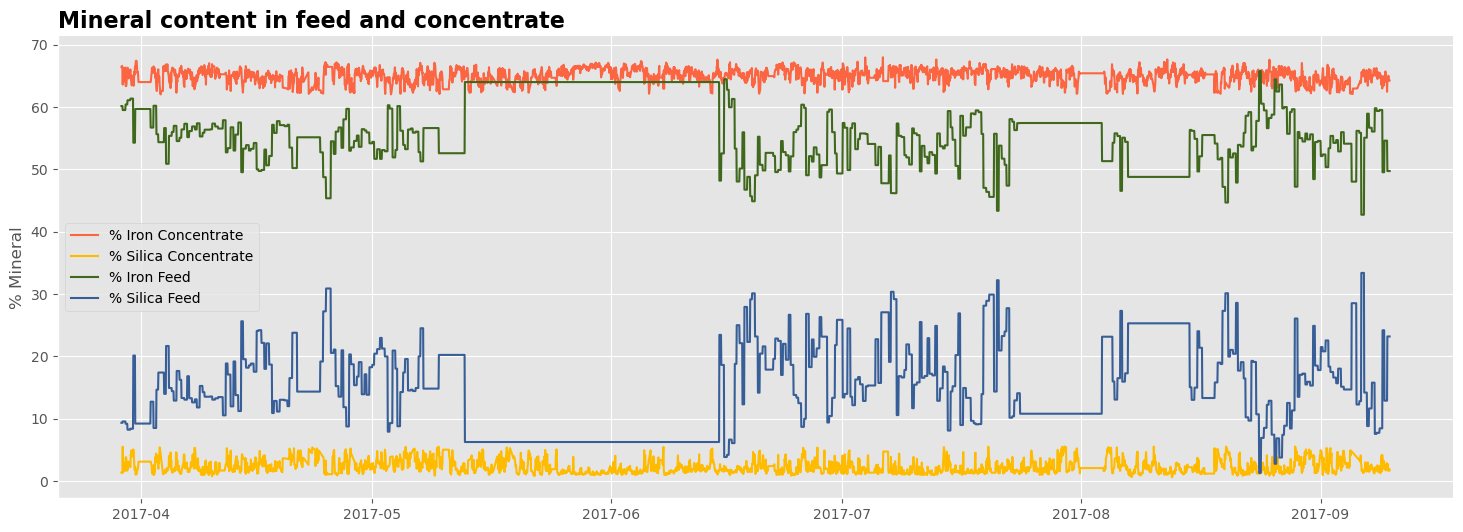

In [126]:
content = ['% Iron Concentrate', '% Silica Concentrate', '% Iron Feed', '% Silica Feed']
palette = ['#FB6542', '#FFBB00', '#3F681C', '#375E97']

# Plot mineral content before and after flotation
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(18,6))
for pct, color in zip(content, palette):
    ax.plot(df.index.values, pct, data=df, color=color)
ax.set_title('Mineral content in feed and concentrate',
             loc='left', weight='bold', size=16)
ax.set_ylabel('% Mineral')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='center left')
plt.show()

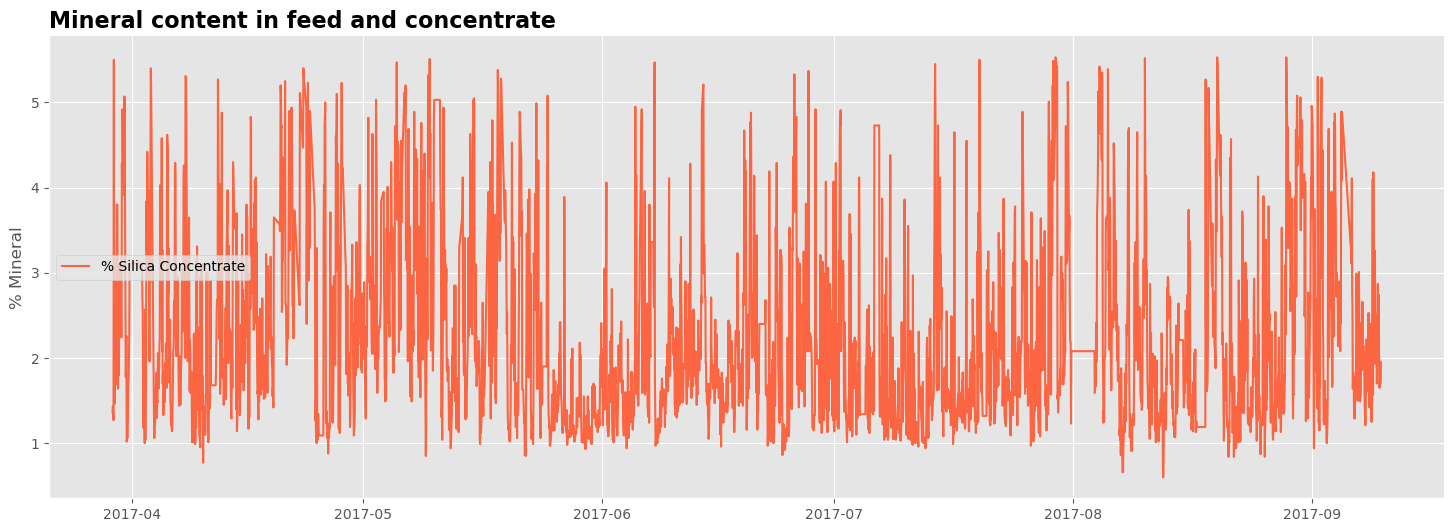

In [127]:
mask_test = ['% Silica Concentrate']


# Plot mineral content before and after flotation
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(18,6))
for pct, color in zip(mask_test, palette):
    ax.plot(df.index.values, pct, data=df, color=color)
ax.set_title('Mineral content in feed and concentrate',
             loc='left', weight='bold', size=16)
ax.set_ylabel('% Mineral')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='center left')
plt.show()

Both  and  are kept and moved to the front of the dataframe, since we now forecast them jointly instead of treating one as an excluded feature. The data are then normalized as they have different units and scales.

In [128]:
# Move both targets (`% Silica Concentrate`, `% Iron Concentrate`) to the
# front so they land in columns 0 and 1 after scaling. Both are now kept
# as targets (not dropped) since we forecast them jointly.
cols = list(df)
cols.insert(0, cols.pop(cols.index('% Silica Concentrate')))
cols.insert(1, cols.pop(cols.index('% Iron Concentrate')))
df = df.loc[:, cols]
df.to_csv('./Flotation_Dataset_by_Hour.csv')  # For safekeeping

n_targets = 2   # % Silica Concentrate, % Iron Concentrate

# Normalize all data (both targets + all predictor columns)
values = df.values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)
scaled[0]  # Show first element of the array

array([0.15415822, 0.73657718, 0.75694444, 0.25023372, 0.16189423,
       0.27711237, 0.58557836, 0.37673081, 0.10208468, 0.17704192,
       0.13203764, 0.1814062 , 0.1435014 , 0.96944319, 0.33797338,
       0.33169233, 0.8444825 , 0.83210796, 0.96760668, 0.61113931,
       0.51765712, 0.55480014, 0.60590942])

The preprocessing stage involves framing the dataset as a supervised learning problem where we forecast the *%silica in concentrate* at the current hour (*t*) given the parameters (i.e., raw materials, environment, process) in prior time steps (*t-n*). We transform the dataset using the `series_to_supervised()` function below, which was adapted from the blog [Machine Learning Mastery](https://machinelearningmastery.com/convert-time-series-supervised-learning-problem-python/) by Jason Brownlee.

In [129]:
# Convert series to supervised learning
def series_to_supervised(data, n_in=1, n_out=1, n_targets=1, dropnan=True):
    """
    Frame a time series as a supervised learning dataset.
    Arguments:
        data: Sequence of observations as a list or NumPy array.
        n_in: Number of lag observations as input (X).
        n_out: Number of observations as output (y).
        n_targets: Number of leading columns in `data` that are forecast
            targets (kept at time t); the rest are dropped at time t.
        dropnan: Boolean whether or not to drop rows with NaN values.
    Returns:
        Pandas DataFrame of series framed for supervised learning.
    """
    n_vars = 1 if type(data) is list else data.shape[1]
    df = pd.DataFrame(data)
    cols, names = list(), list()

    for i in range(n_in, 0, -1):   # Input sequence (t-n, ... t-1)
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]

    for i in range(0, n_out):      # Forecast sequence (t, t+1, ... t+n)
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]

    agg = pd.concat(cols, axis=1)  # Put it all together
    agg.columns = names
    if dropnan:                    # Drop rows with NaN values
        agg.dropna(inplace=True)

    # Drop t-columns we don't want to predict (keep only the first n_targets)
    drop_cols = ['var'+str(i)+'(t)' for i in range(n_targets+1, n_vars+1)]
    agg.drop(columns=drop_cols, axis=1, inplace=True)
    return agg

In [148]:
n_features = scaled.shape[1] - n_targets     # Number of predictor inputs (excludes target columns)
print(n_features, scaled.shape[1])
n_hours = 6                 # Number of past hours of input data the LSTM sees per prediction
n_obs = n_hours*n_features

print(n_hours, n_features, n_obs, n_hours*n_features)

reframed = series_to_supervised(scaled, n_in=n_hours, n_out=1, n_targets=n_targets)
reframed  # Show reframed dataset

21 23
6 21 126 126


,var1(t-6),var2(t-6),var3(t-6),var4(t-6),var5(t-6),var6(t-6),var7(t-6),var8(t-6),var9(t-6),var10(t-6),...,var16(t-1),var17(t-1),var18(t-1),var19(t-1),var20(t-1),var21(t-1),var22(t-1),var23(t-1),var1(t),var2(t)
6,0.154158,0.736577,0.756944,0.250234,0.161894,0.277112,0.585578,0.376731,0.102085,0.177042,...,0.332090,0.983130,0.959232,0.979107,0.522160,0.518453,0.523617,0.562292,0.174442,0.706376
7,0.168357,0.758389,0.756944,0.250234,0.318608,0.160522,0.573122,0.461197,0.040537,0.176707,...,0.332243,0.995571,0.987833,0.998089,0.333980,0.511524,0.502228,0.563115,0.221095,0.709732
8,0.148073,0.770134,0.756944,0.250234,0.222157,0.469035,0.541306,0.454921,0.420008,0.176921,...,0.331978,0.995330,0.984582,0.997532,0.772176,0.745063,0.635303,0.718838,0.245436,0.348993
9,0.135903,0.731544,0.756944,0.250234,0.090718,0.310594,0.536103,0.534718,0.134119,0.176345,...,0.331843,0.995090,0.981331,0.997563,0.831097,0.842502,0.698256,0.773554,0.225152,0.642617
10,0.993915,0.265101,0.729167,0.257089,0.211229,0.150199,0.582031,0.575845,0.037073,0.175892,...,0.333147,0.994849,0.978080,0.999393,0.830425,0.845567,0.698208,0.782014,0.470588,0.442953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3943,0.375254,0.416107,0.516059,0.361172,0.317576,0.357836,0.333867,0.203449,0.225074,0.908847,...,0.661298,0.351829,0.456201,0.373830,0.469604,0.620533,0.410211,0.463157,0.212982,0.503356
3944,0.460446,0.377517,0.516059,0.361172,0.354343,0.316813,0.380058,0.129313,0.235793,0.910187,...,0.653347,0.318795,0.454236,0.358371,0.457349,0.627511,0.395644,0.458078,0.225152,0.466443
3945,0.377282,0.070470,0.516059,0.361172,0.457982,0.673250,0.694981,0.154866,0.554262,0.909496,...,0.685435,0.321966,0.455722,0.352168,0.459382,0.624578,0.394505,0.457922,0.243408,0.375839
3946,0.356998,0.369128,0.304253,0.682144,0.439060,0.550283,0.096706,0.121518,0.513948,0.907571,...,0.726851,0.322014,0.457108,0.449041,0.459311,0.621527,0.400557,0.458071,0.275862,0.369128


Column `var1(t-1)` until `var22(t-1)` are our features/inputs. Measured values of the inputs are lagged 1 hour before the target `var1(t)` (*%silica in concentrate* at time *t*).

Transformed data is further split into three sets: training (60%), validation (20%), and testing (20%). Flotation data in the period between `2017-03-29 12:00` and `2017-08-08 00:00` is used for training/validation purpose, totaling 3157 hours.

In [149]:
# Define row size of each split
n_train = int(np.round(len(reframed)*.60))
n_valid = int(np.round(len(reframed)*.20))
n_test = int(np.round(len(reframed)*.20))

# Split dataset by row size
values = reframed.values
train = values[:n_train, :]
valid = values[n_train:(n_train+n_valid), :]
test = values[(n_train+n_valid):, :]

# Column layout of `reframed`: n_hours consecutive lag blocks, each with
# (n_features + n_targets) columns ordered [target_1(t-k), ..., target_n(t-k),
# feature_1(t-k), ...], for k = n_hours ... 1, followed by the two real
# targets at time t (last n_targets columns). The targets' own lags appear
# at the START of every lag block, not just in the most recent one, so we
# build a boolean mask that drops the first n_targets columns of each block
# instead of relying on a fixed-offset slice.
n_vars = n_features + n_targets
input_mask = np.ones(n_obs, dtype=bool)
for block in range(n_hours):
    start = block * n_vars
    input_mask[start:start + n_targets] = False

train_X, train_y = train[:, :n_obs][:, input_mask], train[:, -n_targets:]
print(train_X.shape, train_y.shape)
valid_X, valid_y = valid[:, :n_obs][:, input_mask], valid[:, -n_targets:]
test_X, test_y = test[:, :n_obs][:, input_mask], test[:, -n_targets:]

n_features -= n_targets      # Number of inputs for forecast (targets' own lags excluded from X)

# Reshape inputs (X) to be 3D [samples, timesteps, features]
train_X = train_X.reshape((train_X.shape[0], n_hours, n_features))
valid_X = valid_X.reshape((valid_X.shape[0], n_hours, n_features))
test_X = test_X.reshape((test_X.shape[0], n_hours, n_features))

print(  # Show the final shape of each set
    f'Training set  : {train_X.shape}, {train_y.shape}',
    f'\nValidation set: {valid_X.shape}, {valid_y.shape}',
    f'\nTesting set   : {test_X.shape}, {test_y.shape}')

(2365, 114) (2365, 2)
Training set  : (2365, 6, 19), (2365, 2) 
Validation set: (788, 6, 19), (788, 2) 
Testing set   : (789, 6, 19), (789, 2)


# Building and Training Model

Forecasting gangue in flotation concentrate is a time-series related problem. A variation of the recurrent neural networks (RNN), called the long short-term memory (LSTM), is a deep learning approach that can be implemented to solve the problem.
> *LSTMs have an edge over conventional feed-forward neural networks and RNN in many ways. This is because of their property of selectively remembering patterns for long durations of time.* -[Analytics Vidhya](https://www.analyticsvidhya.com/blog/2017/12/fundamentals-of-deep-learning-introduction-to-lstm/)

Model construction and training is done with [Keras](https://tensorflow.org/api_docs/python/tf/keras), a Python deep learning library. The model is made up of two [LSTM](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM) layers, each with 16 memory cells, and followed by a fully-connected ([Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)) layer. In training, the data are grouped into mini batches of 16 training samples. The training process is run for 100 epochs (one epoch is the number of passes needed to complete the entire training samples).

In [150]:
model = Sequential([   # Define a sequential model
    LSTM(units=16,
         return_sequences=True,
         input_shape=(train_X.shape[1],
                      train_X.shape[2])),
    LSTM(units=16),
    Dense(n_targets)   # One output per target: [silica, iron]
])
model.compile(
    loss='mae',        # Mean absolute error, averaged across both outputs
    optimizer='adam')  # Learning rate = 0.001
model.summary()        # Display model's architecture

c:\Users\COMPUTAEX\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 6, 16)          │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,450 (17.38 KB)

 Trainable params: 4,450 (17.38 KB)

 Non-trainable params: 0 (0.00 B)

In [151]:
history = model.fit(   # Fit on training data
    train_X,
    train_y,
    epochs=100,
    batch_size=16,
    validation_data=(  # Supply validation data
        valid_X,
        valid_y),
    verbose=2,
    shuffle=False,
    callbacks=ModelCheckpoint(  # Save model
        './LSTM_Flotation_Gangue.keras'))

Epoch 1/100
148/148 - 3s - 17ms/step - loss: 0.1809 - val_loss: 0.1442
Epoch 2/100
148/148 - 1s - 4ms/step - loss: 0.1678 - val_loss: 0.1431
Epoch 3/100
148/148 - 1s - 4ms/step - loss: 0.1676 - val_loss: 0.1433
Epoch 4/100
148/148 - 1s - 4ms/step - loss: 0.1676 - val_loss: 0.1425
Epoch 5/100
148/148 - 1s - 3ms/step - loss: 0.1675 - val_loss: 0.1423
Epoch 6/100
148/148 - 1s - 4ms/step - loss: 0.1673 - val_loss: 0.1418
Epoch 7/100
148/148 - 0s - 3ms/step - loss: 0.1673 - val_loss: 0.1406
Epoch 8/100
148/148 - 0s - 3ms/step - loss: 0.1673 - val_loss: 0.1406
Epoch 9/100
148/148 - 1s - 3ms/step - loss: 0.1674 - val_loss: 0.1406
Epoch 10/100
148/148 - 0s - 3ms/step - loss: 0.1671 - val_loss: 0.1406
Epoch 11/100
148/148 - 0s - 3ms/step - loss: 0.1668 - val_loss: 0.1408
Epoch 12/100
148/148 - 1s - 3ms/step - loss: 0.1664 - val_loss: 0.1407
Epoch 13/100
148/148 - 1s - 3ms/step - loss: 0.1651 - val_loss: 0.1418
Epoch 14/100
148/148 - 0s - 3ms/step - loss: 0.1651 - val_loss: 0.1423
Epoch 15/100
1

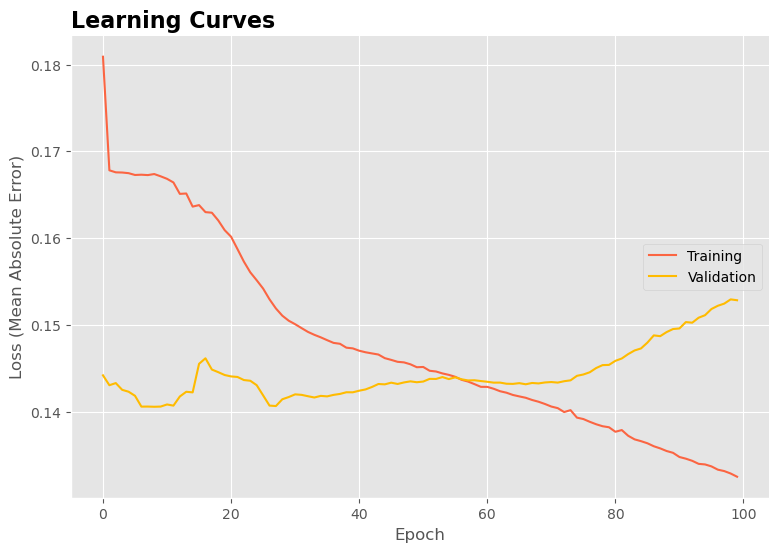

In [152]:
# Extract losses from training history
train_loss = history.history['loss']
valid_loss = history.history['val_loss']

# Plot learning curves
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(9,6))
ax.plot(train_loss, color=palette[0], label='Training')
ax.plot(valid_loss, color=palette[1], label='Validation')
ax.set_title('Learning Curves', loc='left', weight='bold', size=16)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (Mean Absolute Error)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='center right')
plt.show()

The plot above indicates that the model exhibits a good fit where training and validation losses decrease to a point of stability and there is minimal gap between the two values.

In [153]:
print(f'Best training loss   = {min(train_loss):.4f}',
      f'at epoch {train_loss.index(min(train_loss))}',
      f'\nBest validation loss = {min(valid_loss):.4f}',
      f'at epoch {valid_loss.index(min(valid_loss))}')

Best training loss   = 0.1325 at epoch 99 
Best validation loss = 0.1406 at epoch 8


# Forecasting with LSTM

Forecasting is performed using the trained model and on the data that was not included during training/validation process. Forecasts and actual values are inverted back into their original scales before calculating error scores for the model. Two error metrics are considered in the forecast evaluation: (1) mean absolute error, and (2) root mean squared error.

In [154]:
print("model expects:", model.input_shape)
print("test_X shape :", test_X.shape)

# Reshape test data before predicting
test_X = test_X.reshape((test_X.shape[0], n_hours, n_features))

# Make prediction using test features -> yhat has shape (n_samples, n_targets)
yhat = model.predict(test_X)

test_X = test_X.reshape((test_X.shape[0], n_hours*n_features))

# Invert scaling for forecasts and actuals.
# `scaler` was fit on the FULL column set (both targets at columns 0-1),
# but test_X no longer contains the targets or their own lags as inputs, so
# we can't reconstruct a scaler-width row from test_X anymore. Instead,
# build a dummy array of the width the scaler expects, place the target
# values in columns 0-1 (where the scaler put them), and fill the rest with
# zeros. Since MinMaxScaler scales each column independently, the other
# columns' values don't affect the inverse-transform of columns 0-1.
n_scaler_features = scaler.n_features_in_   # width the scaler was actually fit on

dummy_yhat = np.zeros((yhat.shape[0], n_scaler_features))
dummy_yhat[:, :n_targets] = yhat
inv_yhat = scaler.inverse_transform(dummy_yhat)[:, :n_targets]

dummy_y = np.zeros((test_y.shape[0], n_scaler_features))
dummy_y[:, :n_targets] = test_y
inv_y = scaler.inverse_transform(dummy_y)[:, :n_targets]

# Split back into named series: column 0 = silica, column 1 = iron
inv_yhat_silica, inv_yhat_iron = inv_yhat[:, 0], inv_yhat[:, 1]
inv_y_silica, inv_y_iron = inv_y[:, 0], inv_y[:, 1]

# Calculate error scores per target
r2_silica = r2_score(inv_y_silica, inv_yhat_silica)
r2_iron = r2_score(inv_y_iron, inv_yhat_iron)
mae_silica = mean_absolute_error(inv_y_silica, inv_yhat_silica)
rmse_silica = np.sqrt(mean_squared_error(inv_y_silica, inv_yhat_silica))
mae_iron = mean_absolute_error(inv_y_iron, inv_yhat_iron)
rmse_iron = np.sqrt(mean_squared_error(inv_y_iron, inv_yhat_iron))

print(32*'-'+'\nFORECAST EVALUATION\n'+32*'-',
      f'\n% Silica Concentrate  -> R2: {r2_silica:.4f}, MAE: {mae_silica:.4f}, RMSE: {rmse_silica:.4f}',
      f'\n% Iron Concentrate    -> R2: {r2_iron:.4f}, MAE: {mae_iron:.4f}, RMSE: {rmse_iron:.4f}')

model expects: (None, 6, 19)
test_X shape : (789, 6, 19)
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
--------------------------------
FORECAST EVALUATION
-------------------------------- 
% Silica Concentrate  -> R2: -0.3729, MAE: 1.0359, RMSE: 1.3480 
% Iron Concentrate    -> R2: -0.4976, MAE: 1.0356, RMSE: 1.3725


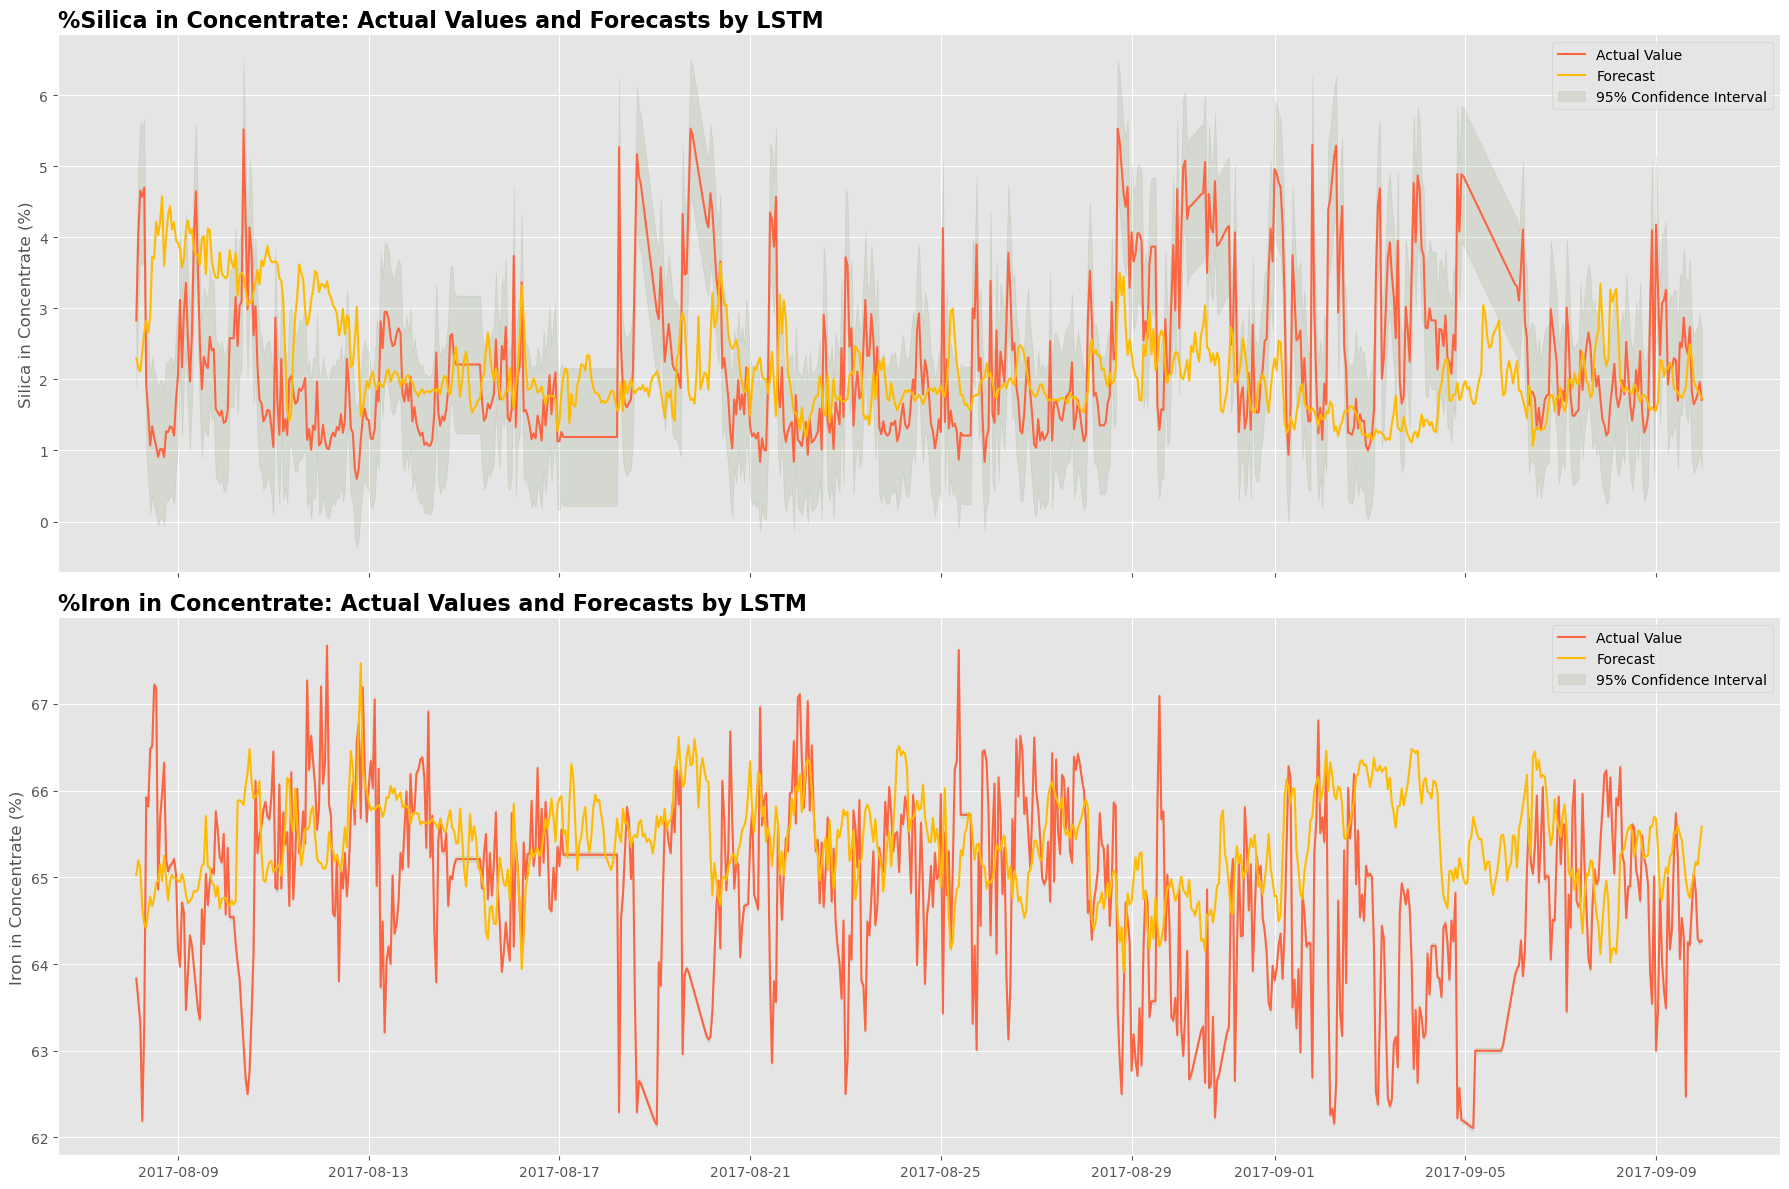

In [155]:
# Define date as x-axis
test_date = df.index[-inv_y_silica.shape[0]:]

# Confidence interval 95% (Z-value 1.96)
ci_silica = 1.96*np.std(inv_y_silica)/np.mean(inv_y_silica)
ci_iron = 1.96*np.std(inv_y_iron)/np.mean(inv_y_iron)

# Plot actual values and forecasts for both targets
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18,12), sharex=True)

ax1.plot(test_date, inv_y_silica, color=palette[0], label='Actual Value')
ax1.plot(test_date, inv_yhat_silica, color=palette[1], label='Forecast')
ax1.fill_between(test_date, (inv_y_silica-ci_silica), (inv_y_silica+ci_silica),
                  color=palette[2], alpha=.1, label='95% Confidence Interval')
ax1.set_title('%Silica in Concentrate: Actual Values and Forecasts by LSTM',
              loc='left', weight='bold', size=16)
ax1.set_ylabel('Silica in Concentrate (%)')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend()

ax2.plot(test_date, inv_y_iron, color=palette[0], label='Actual Value')
ax2.plot(test_date, inv_yhat_iron, color=palette[1], label='Forecast')
ax2.fill_between(test_date, (inv_y_iron-ci_iron), (inv_y_iron+ci_iron),
                  color=palette[2], alpha=.1, label='95% Confidence Interval')
ax2.set_title('%Iron in Concentrate: Actual Values and Forecasts by LSTM',
              loc='left', weight='bold', size=16)
ax2.set_ylabel('Iron in Concentrate (%)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend()

plt.tight_layout()
plt.show()